# JaXGB: one year, three parameters
Run all cells (Colab CPU, Python ≥3.12). Everything is generated here. Moving equal-arm LISA response; known instrument noise; fixed sky/orientation. Continuous Fourier/WDM and gapped WDM only.

### 1. Install and import

In [1]:
import sys, os, subprocess, importlib.metadata as metadata
import warnings
warnings.filterwarnings("ignore", message="IProgress not found.*")
assert sys.version_info >= (3, 12), "Use a Python 3.12+ runtime."
packages = {"jaxgb": "0.2.1", "lisaorbits": "3.1.0",
            "lisaanalysistools": "1.2.8", "wdm-transform": "0.5.0",
            "emcee": "3.1.6"}
def installed_version(name):
    try: return metadata.version(name)
    except metadata.PackageNotFoundError: return None
if any(installed_version(name) != version for name, version in packages.items()):
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q",
                           *[f"{name}=={version}" for name, version in packages.items()]])
    for name in ["numpy", "scipy", "h5py", "jax"]:
        loaded = sys.modules.get(name)
        if loaded and getattr(loaded, "__version__", None) != installed_version(name):
            raise RuntimeError("Packages updated: restart runtime, then Run all again.")
os.environ.setdefault("OPENBLAS_NUM_THREADS", "4")
os.environ.setdefault("JAX_PLATFORMS", "cpu")
import jax
jax.config.update("jax_enable_x64", True)
import jax.numpy as jnp
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import eigh
from scipy.optimize import minimize
from scipy.signal import hilbert
import emcee
from jaxgb.jaxgb import JaxGB
from lisaorbits import EqualArmlengthOrbits
from lisatools.sensitivity import get_sensitivity, A2TDISens
from wdm_transform import WDM, TimeSeries, get_backend
plt.rcParams.update({"font.size": 11, "figure.figsize": (11, 3.5)})
BLUE, ORANGE, OLIVE = "#2463a6", "#c46b27", "#628342"
print("Python", sys.version.split()[0], "| JAX", jax.__version__)

Python 3.12.12 | JAX 0.11.1


### 2. Source and settings

In [2]:
T = 365.25 * 86400
N, NT, NSLOW = 2**18, 64, 1024
DT, DAY = T / N, 86400
F0, FDOT, A0 = 3e-3, 1e-15, 3.6448032791850685e-23
GAPS = [(60, 67), (150, 157), (240, 247)]
TAPER_DAYS, GUARD_ROWS = 2., 3
SEED = 20261002
response = JaxGB(EqualArmlengthOrbits(), t_obs=T, t0=0, n=NSLOW)

@jax.jit
def binary(theta):
    # theta = [T * delta_f0, T**2 * delta_fdot, A / A0]
    parameters = jnp.array([F0 + theta[0] / T, FDOT + theta[1] / T**2,
                            A0 * theta[2], 1., .4, .3, .8, .2])
    a, e, _ = response.get_tdi(parameters, tdi_generation=2, tdi_combination="AET")
    return jnp.stack([a, e]), response.get_kmin(parameters[0])

time = np.arange(N) * DT
frequency = np.fft.rfftfreq(N, DT)
psd = get_sensitivity(np.maximum(frequency, frequency[1]),
                      sens_fn=A2TDISens, model="scirdv1")
injection = np.array([0., 0., 1.])
h, first = binary(injection)
source_bins = np.arange(int(first) - 3, int(first) + NSLOW + 3)
columns = np.arange(round(F0 * 2 * T / NT) - 2, round(F0 * 2 * T / NT) + 3)
print(f"One year | f0 = {F0 * 1e3:g} mHz | fdot = {FDOT:g} Hz/s | A = {A0:.6g}")

One year | f0 = 3 mHz | fdot = 1e-15 Hz/s | A = 3.6448e-23


### 3. Simulate A/E

In [3]:
rng = np.random.default_rng(SEED)
spectrum = np.zeros((2, len(frequency)), complex)
spectrum[:, int(first):int(first) + NSLOW] = np.asarray(h) / DT
signal = np.fft.irfft(spectrum, n=N, axis=1)
noise = np.sqrt(N * psd / (4 * DT)) * (
    rng.normal(size=spectrum.shape) + 1j * rng.normal(size=spectrum.shape))
for k in [0, -1]:
    noise[:, k] = rng.normal(size=2) * np.sqrt(N * psd[k] / (2 * DT))
data = signal + np.fft.irfft(noise, n=N, axis=1)
available = np.ones(N, bool)
for start, stop in GAPS:
    available &= ~((time >= start * DAY) & (time < stop * DAY))
gapped_data = np.where(available, data, np.nan)
del spectrum, noise

### 4. Raised-cosine tapers
Two days at both observation ends and on the available side of every gap. The same windows act on data and templates. Tapers suppress leakage; they do not eliminate it.

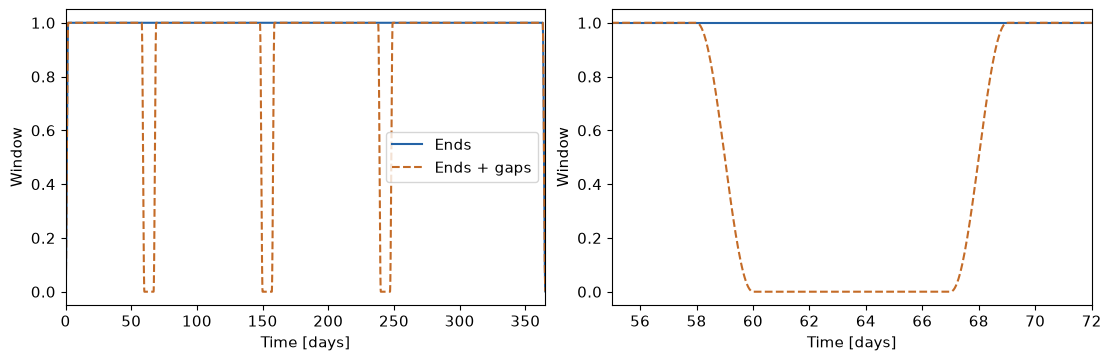

WDM rows kept: 64 continuous; 30 gapped


In [4]:
def cosine_ramp(distance):
    return .5 * (1 - np.cos(np.pi * np.clip(distance / (TAPER_DAYS * DAY), 0, 1)))

end_window = cosine_ramp(time) * cosine_ramp(time[-1] - time)
gap_window = end_window.copy()
for start, stop in GAPS:
    # Ramp down before the gap and up after it; zero throughout the gap.
    distance = np.maximum(start * DAY - time, time - stop * DAY)
    gap_window *= cosine_ramp(distance)
assert end_window[0] == end_window[-1] == 0
assert np.all(gap_window[~available] == 0)

row_spacing = T / NT
row_time = np.arange(NT) * row_spacing
half_cell = row_spacing / 2
margin = TAPER_DAYS * DAY + GUARD_ROWS * row_spacing
keep_continuous = np.ones(NT, bool)  # retain every row for the equivalent continuous fit
keep_gapped = (row_time - half_cell > margin) & (row_time + half_cell < T - margin)
for start, stop in GAPS:
    keep_gapped &= ~((row_time + half_cell >= start * DAY - margin)
                     & (row_time - half_cell <= stop * DAY + margin))

fig, axes = plt.subplots(1, 2, layout="constrained")
for axis, limits in zip(axes, [(0, 365.25), (55, 72)]):
    axis.plot(time[::32] / DAY, end_window[::32], color=BLUE, label="Ends")
    axis.plot(time[::32] / DAY, gap_window[::32], color=ORANGE, ls="--", label="Ends + gaps")
    axis.set(xlim=limits, ylim=(-.05, 1.05), xlabel="Time [days]", ylabel="Window")
axes[0].legend()
plt.show()
print("WDM rows kept:", keep_continuous.sum(), "continuous;", keep_gapped.sum(), "gapped")

### 5. Time and frequency views

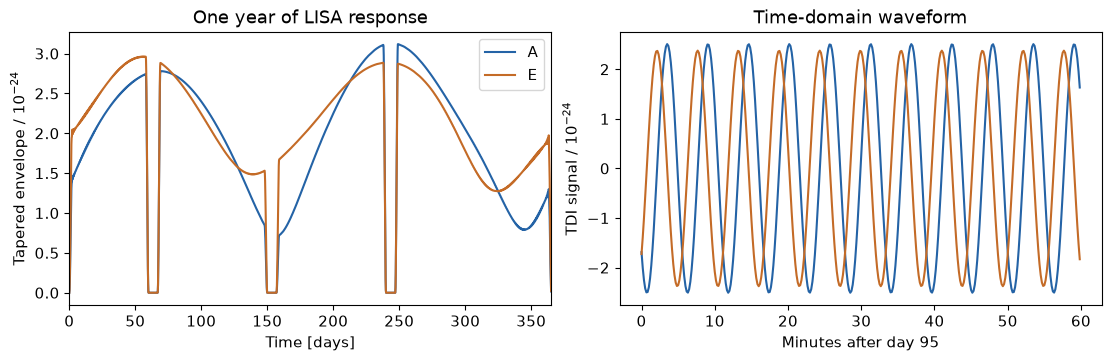

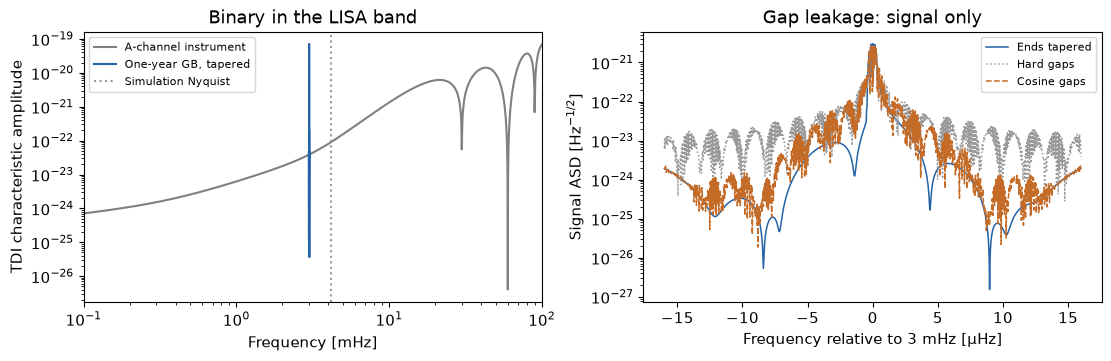

In [5]:
fig, axes = plt.subplots(1, 2, layout="constrained")
for channel, color, label in [(0, BLUE, "A"), (1, ORANGE, "E")]:
    envelope = abs(hilbert(signal[channel])) * gap_window
    axes[0].plot(time[::128] / DAY, envelope[::128] / 1e-24, color=color, label=label)
    dense_time = 95 * DAY + np.arange(0, 3600, 10.)
    source_frequency = (int(first) + np.arange(NSLOW)) / T
    dense = 2 / T * np.real(np.asarray(h[channel]) @ np.exp(
        2j * np.pi * source_frequency[:, None] * dense_time[None, :]))
    axes[1].plot((dense_time - 95 * DAY) / 60, dense / 1e-24, color=color, label=label)
axes[0].set(xlabel="Time [days]", ylabel=r"Tapered envelope / $10^{-24}$",
            title="One year of LISA response", xlim=(0, 365.25))
axes[1].set(xlabel="Minutes after day 95", ylabel=r"TDI signal / $10^{-24}$",
            title="Time-domain waveform")
axes[0].legend()
plt.show()

signal_fft = DT * np.fft.rfft(signal, axis=1)
end_fft = DT * np.fft.rfft(signal * end_window, axis=1)
hard_gap_fft = DT * np.fft.rfft(signal * available * end_window, axis=1)
gap_fft = DT * np.fft.rfft(signal * gap_window, axis=1)
fig, axes = plt.subplots(1, 2, layout="constrained")
context = np.geomspace(1e-4, .1, 2000)
context_psd = get_sensitivity(context, sens_fn=A2TDISens, model="scirdv1")
axes[0].loglog(context * 1e3, np.sqrt(context * context_psd), color=".5", label="A-channel instrument")
near = abs(frequency - F0) < 16e-6
axes[0].loglog(frequency[near] * 1e3, 2 * frequency[near] * abs(end_fft[0, near]),
               color=BLUE, label="One-year GB, tapered")
axes[0].axvline(frequency[-1] * 1e3, color=".6", ls=":", label="Simulation Nyquist")
axes[0].set(xlim=(.1, 100), xlabel="Frequency [mHz]", ylabel="TDI characteristic amplitude",
            title="Binary in the LISA band")
for values, label, color, style in [(end_fft, "Ends tapered", BLUE, "-"),
                                   (hard_gap_fft, "Hard gaps", "0.6", ":"),
                                   (gap_fft, "Cosine gaps", ORANGE, "--")]:
    axes[1].semilogy((frequency[near] - F0) * 1e6, np.sqrt(2 / T) * abs(values[0, near]),
                     color=color, ls=style, lw=1.1, label=label)
axes[1].set(xlabel="Frequency relative to 3 mHz [µHz]", ylabel=r"Signal ASD [Hz$^{-1/2}$]",
            title="Gap leakage: signal only")
for axis in axes: axis.legend(fontsize=8)
plt.show()

### 6. Public WDM transform

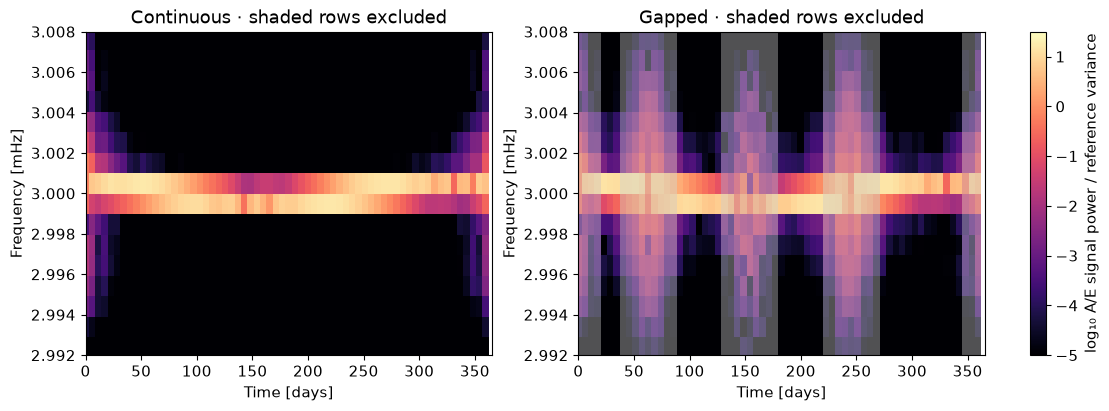

In [6]:
def wdm(samples):
    return WDM.from_time_series(TimeSeries(samples, dt=DT), nt=NT, backend="jax")

reference_sd = np.sqrt(N * psd[round(F0 * T)] / (2 * DT))
fig, axes = plt.subplots(1, 2, figsize=(11, 4), layout="constrained")
for axis, window, keep, label in zip(axes, [end_window, gap_window],
                                    [keep_continuous, keep_gapped], ["Continuous", "Gapped"]):
    grid = wdm(signal * window)
    grid_frequency = np.asarray(grid.freq_grid) * 1e3
    near = abs(grid_frequency - 3) < .008
    power = np.sum(np.asarray(grid.coeffs)**2, axis=0) / reference_sd**2
    image = axis.pcolormesh(row_time / DAY, grid_frequency[near],
                           np.log10(np.maximum(power[:, near].T, 1e-8)),
                           cmap="magma", vmin=-5, vmax=1.5, shading="nearest")
    for center in row_time[~keep]:
        axis.axvspan((center - half_cell) / DAY, (center + half_cell) / DAY,
                     color=".8", alpha=.4, linewidth=0)
    axis.set(title=label + " · shaded rows excluded", xlim=(0, 365.25),
             xlabel="Time [days]", ylabel="Frequency [mHz]", ylim=(2.992, 3.008))
fig.colorbar(image, ax=axes.tolist(), label="log₁₀ A/E signal power / reference variance")
plt.show()

### 7. Matched continuous likelihoods
Continuous fits use the same tapered Fourier band. Public WDM re-expresses that band, keeping all time rows and full covariance. Gapped WDM uses guard rows and checked diagonal weights.

In [7]:
def wdm_atoms(columns):
    # Public inverse of unit coefficients gives the public analysis basis / N.
    atoms = np.empty((NT * len(columns), N))
    for start in range(0, len(atoms), 8):
        index = np.arange(start, min(start + 8, len(atoms)))
        coefficients = np.zeros((len(index), NT, N // NT + 1))
        coefficients[np.arange(len(index)), index // len(columns),
                     columns[index % len(columns)]] = 1
        basis = WDM(coefficients, dt=DT, backend=get_backend("jax"))
        atoms[index] = np.asarray(basis.to_time_series().data) * N / reference_sd
    return atoms

def prepare(atoms, window):
    # Apply the identical window to observations, templates, and noise covariance.
    atoms = atoms * window
    observed, injected = data @ atoms.T, signal @ atoms.T
    atom_fft = np.fft.rfft(atoms, axis=1)
    del atoms
    projection = (2 / N / DT) * atom_fft[:, source_bins].conj()
    atom_fft *= np.sqrt(psd / (N * DT))
    atom_fft[:, [0, -1]] /= np.sqrt(2)
    covariance = np.real(atom_fft @ atom_fft.conj().T)
    return observed, injected, projection, covariance


def make_likelihood(observed, injected, projection, covariance, diagonal=False):
    variance = covariance.diagonal()
    correlation = covariance / np.sqrt(variance[:, None] * variance[None, :])
    if diagonal:
        discrepancy = np.max(abs(eigh(correlation - np.eye(len(variance)), eigvals_only=True)))
        assert discrepancy < .01, f"Add guard rows: covariance discrepancy = {discrepancy:.3g}"
        white_data = observed / np.sqrt(variance)
        white_signal = injected / np.sqrt(variance)
        white_projection = projection / np.sqrt(variance[:, None])
        rank = len(variance)
    else:
        eigenvalues, vectors = eigh(covariance)
        retained = eigenvalues > eigenvalues[-1] * 1e-10
        whitening = (vectors[:, retained] / np.sqrt(eigenvalues[retained])).T
        white_data = observed @ whitening.T
        white_signal = injected @ whitening.T
        white_projection = whitening @ projection
        rank, discrepancy = int(retained.sum()), None
    projection_jax, observed_jax = jnp.asarray(white_projection), jnp.asarray(white_data)

    @jax.jit
    def model(theta):
        h, first = binary(theta)
        index = jnp.arange(NSLOW) + first - source_bins[0]
        return jnp.real(h @ projection_jax[:, index].T)

    @jax.jit
    def likelihood(theta):
        return -.5 * jnp.sum((observed_jax - model(theta))**2)

    np.testing.assert_allclose(model(injection), white_signal, atol=1e-9)
    noise_energy = float(np.sum((white_data - white_signal)**2))
    assert abs(noise_energy - 2 * rank) < 5 * np.sqrt(4 * rank)
    return likelihood, dict(snr=float(np.linalg.norm(white_signal)),
                            covariance_discrepancy=None if discrepancy is None else float(discrepancy),
                            kept_modes=rank, total_modes=len(variance),
                            noise_energy=noise_energy)

likelihoods, checks = {}, {}
# Continuous Fourier: tapered data in a declared band, with exact covariance.
fft_bins = np.flatnonzero(abs(frequency - F0) < 3e-6)
reference_fft = np.sqrt(T * psd[round(F0 * T)] / 4)
phase = 2 * np.pi * fft_bins[:, None] * np.arange(N)[None, :] / N
atoms = np.concatenate([np.cos(phase), -np.sin(phase)]) * DT / reference_fft
fft_observed, fft_signal, fft_projection, fft_covariance = prepare(atoms, end_window)
del phase, atoms
likelihoods["Fourier continuous"], checks["Fourier continuous"] = make_likelihood(
    fft_observed, fft_signal, fft_projection, fft_covariance)
direct = DT * np.fft.rfft(data * end_window, axis=1)[:, fft_bins] / reference_fft
np.testing.assert_allclose(fft_observed, np.concatenate([direct.real, direct.imag], axis=1), atol=2e-7)

# Public WDM transform of unit Fourier coordinates in the SAME band.
# Include every time row and all WDM columns touched by this band.
grid_frequency = np.asarray(wdm(signal).freq_grid)
delta_f = NT / (2 * T)
continuous_columns = np.flatnonzero(
    (grid_frequency >= frequency[fft_bins[0]] - 2 * delta_f) &
    (grid_frequency <= frequency[fft_bins[-1]] + 2 * delta_f))
mode_count = 2 * len(fft_bins)
rotation = np.empty((NT * len(continuous_columns), mode_count))
for start in range(0, mode_count, 8):
    index = np.arange(start, min(start + 8, mode_count))
    unit_spectrum = np.zeros((len(index), len(frequency)), complex)
    unit_spectrum[np.arange(len(index)), fft_bins[index % len(fft_bins)]] = (
        np.where(index < len(fft_bins), 1., 1j) * reference_fft / DT)
    unit_time = np.fft.irfft(unit_spectrum, n=N, axis=1)
    coefficients = np.asarray(wdm(unit_time).coeffs)[:, :, continuous_columns]
    rotation[:, index] = coefficients.reshape(len(index), -1).T / reference_sd
# Losing any Fourier mode here would invalidate posterior equivalence.
np.testing.assert_allclose(rotation.T @ rotation, np.eye(mode_count), atol=1e-10)

wdm_observed = fft_observed @ rotation.T
likelihoods["WDM continuous"], checks["WDM continuous"] = make_likelihood(
    wdm_observed, fft_signal @ rotation.T,
    rotation @ fft_projection, rotation @ fft_covariance @ rotation.T)
assert checks["WDM continuous"]["kept_modes"] == checks["Fourier continuous"]["kept_modes"]
# Independent direct forward-transform check on the band-limited observation.
band_spectrum = np.zeros((2, len(frequency)), complex)
band_spectrum[:, fft_bins] = (fft_observed[:, :len(fft_bins)] +
                              1j * fft_observed[:, len(fft_bins):]) * reference_fft / DT
band_time = np.fft.irfft(band_spectrum, n=N, axis=1)
direct = np.asarray(wdm(band_time).coeffs)[:, :, continuous_columns].reshape(2, -1) / reference_sd
np.testing.assert_allclose(wdm_observed, direct, atol=1e-8)

# Gapped WDM: raw time gaps + cosine tapers + guarded row selection.
atoms = wdm_atoms(columns)[np.repeat(keep_gapped, len(columns))]
gap_observed, gap_signal, gap_projection, gap_covariance = prepare(atoms, gap_window)
likelihoods["WDM gapped"], checks["WDM gapped"] = make_likelihood(
    gap_observed, gap_signal, gap_projection, gap_covariance, diagonal=True)
direct = np.asarray(wdm(data * gap_window).coeffs)[:, keep_gapped][:, :, columns].reshape(2, -1) / reference_sd
np.testing.assert_allclose(gap_observed, direct, atol=1e-8)
del atoms, unit_spectrum, unit_time, coefficients, band_spectrum, band_time, direct

# Verify likelihood SHAPE across the prior before running any sampler.
rng_check = np.random.default_rng(42)
points = np.column_stack([rng_check.uniform(-.95, .95, 30),
                          rng_check.uniform(-2.9, 2.9, 30),
                          rng_check.uniform(.31, 1.99, 30)])
fft_ll, wdm_ll = likelihoods["Fourier continuous"], likelihoods["WDM continuous"]
parity_error = max(abs(float(fft_ll(p) - fft_ll(injection)) -
                       float(wdm_ll(p) - wdm_ll(injection))) for p in points)
assert parity_error < 1e-7
print(f"Continuous likelihood parity: max |delta log L difference| = {parity_error:.2g}")
for name, result in checks.items():
    weighting = ("full covariance" if result["covariance_discrepancy"] is None else
                 f"diagonal approximation error {100 * result['covariance_discrepancy']:.3f}%")
    print(f"{name}: SNR {result['snr']:.2f}; modes {result['kept_modes']}; {weighting}")


Continuous likelihood parity: max |delta log L difference| = 1.1e-12
Fourier continuous: SNR 24.97; modes 378; full covariance
WDM continuous: SNR 24.97; modes 378; full covariance
WDM gapped: SNR 16.47; modes 150; diagonal approximation error 0.411%


### 8. Fit f₀, ḟ, A
Local uniform priors: TΔf₀ ∈ [−1,1], T²Δḟ ∈ [−3,3], A/A₀ ∈ [0.3,2]. Two independent emcee ensembles per fit.

In [8]:
def sample(log_likelihood, seed):
    @jax.jit
    def log_posterior(theta):
        inside = ((jnp.abs(theta[0]) < 1) & (jnp.abs(theta[1]) < 3)
                  & (theta[2] > 0.3) & (theta[2] < 2))
        return jnp.where(inside, log_likelihood(theta), -jnp.inf)

    batch = jax.jit(jax.vmap(log_posterior))
    fit = minimize(lambda x: -float(log_posterior(x)), [0.03, -0.15, 1],
                   method="Nelder-Mead", options={"xatol": 1e-7, "maxiter": 1500})
    assert fit.success
    rng = np.random.default_rng(seed)
    chains, diagnostics = [], []
    for run in range(2):
        sampler = emcee.EnsembleSampler(24, 3, lambda x: np.asarray(batch(x)), vectorize=True)
        sampler.random_state = np.random.RandomState(seed + run).get_state()
        start = fit.x + rng.normal(size=(24, 3)) * [0.04, 0.12, 0.04]
        state = sampler.run_mcmc(start, 700)
        sampler.reset()
        sampler.run_mcmc(state, 3500)
        while sampler.iteration < 7500:
            tau = sampler.get_autocorr_time(tol=0)
            if sampler.iteration > 70 * tau.max():
                break
            sampler.run_mcmc(None, 1000)
        chain = sampler.get_chain()
        tau = sampler.get_autocorr_time(tol=0)
        assert sampler.iteration > 50 * tau.max()
        chains.append(chain)
        diagnostics.append(dict(steps=sampler.iteration, tau=tau.tolist(),
                                acceptance=float(sampler.acceptance_fraction.mean())))
    samples = np.concatenate([c.reshape(-1, 3) for c in chains])
    difference = np.abs(chains[0].mean((0, 1)) - chains[1].mean((0, 1))) / samples.std(0)
    assert np.max(difference) < 0.15
    return samples, chains, dict(map=fit.x.tolist(), ensembles=diagnostics,
                                 ensemble_mean_difference_over_sd=difference.tolist(),
                                 quantiles=np.quantile(samples, [0.05, 0.5, 0.95], axis=0).tolist(),
                                 sd=samples.std(0).tolist())

In [9]:
samples, diagnostics = {}, {}
for i, (name, likelihood) in enumerate(likelihoods.items()):
    print("Fitting", name, flush=True)
    samples[name], chains, diagnostics[name] = sample(likelihood, SEED + 100 * i)
    del chains
    print("  done; max independent-ensemble mean difference / SD:",
          round(max(diagnostics[name]["ensemble_mean_difference_over_sd"]), 3), flush=True)

Fitting Fourier continuous


  done; max independent-ensemble mean difference / SD: 0.025


Fitting WDM continuous


  done; max independent-ensemble mean difference / SD: 0.024


Fitting WDM gapped


  done; max independent-ensemble mean difference / SD: 0.054


### 9. Posteriors and checks

Fourier continuous | injection in 90% intervals: [ True  True  True]
WDM continuous | injection in 90% intervals: [ True  True  True]
WDM gapped | injection in 90% intervals: [ True  True  True]


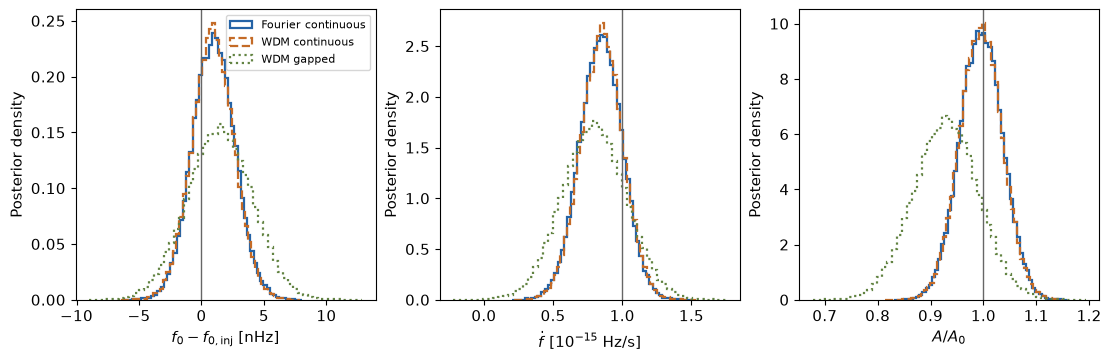

Fourier continuous | production / autocorrelation time: [99.1 94. ]
WDM continuous | production / autocorrelation time: [97.7 99.5]
WDM gapped | production / autocorrelation time: [90.3 93.4]
Gapped / continuous WDM posterior SD: [1.55 1.51 1.53]
Packages: {'jaxgb': '0.2.1', 'lisaorbits': '3.1.0', 'lisaanalysistools': '1.2.8', 'wdm-transform': '0.5.0', 'emcee': '3.1.6'}
Continuous mean difference / SD: [0.034 0.03  0.017]
Continuous WDM / Fourier posterior SD: [0.992 0.995 0.99 ]


In [10]:
fig, axes = plt.subplots(1, 3, layout="constrained")
for (name, values), color, style in zip(samples.items(), [BLUE, ORANGE, OLIVE], ["-", "--", ":"]):
    physical = np.column_stack([values[:, 0] / T * 1e9,
                               (FDOT + values[:, 1] / T**2) * 1e15, values[:, 2]])
    for i, axis in enumerate(axes):
        axis.hist(physical[:, i], bins=55, density=True, histtype="step",
                  color=color, ls=style, lw=1.6, label=name)
    lo, median, hi = np.quantile(values, [.05, .5, .95], axis=0)
    print(name, "| injection in 90% intervals:", (lo < injection) & (injection < hi))
for axis, truth, label in zip(axes, [0, 1, 1],
    [r"$f_0-f_{0,\mathrm{inj}}$ [nHz]", r"$\dot f$ [$10^{-15}$ Hz/s]", r"$A/A_0$"]):
    axis.axvline(truth, color=".4", lw=1)
    axis.set(xlabel=label, ylabel="Posterior density")
axes[0].legend(fontsize=8)
plt.show()

for name, result in diagnostics.items():
    ratios = [run["steps"] / max(run["tau"]) for run in result["ensembles"]]
    assert min(ratios) > 50
    print(name, "| production / autocorrelation time:", np.round(ratios, 1))
print("Gapped / continuous WDM posterior SD:",
      np.round(samples["WDM gapped"].std(0) / samples["WDM continuous"].std(0), 2))
print("Packages:", {name: installed_version(name) for name in packages})
mean_difference = abs(samples["Fourier continuous"].mean(0) -
                      samples["WDM continuous"].mean(0)) / samples["Fourier continuous"].std(0)
width_ratio = samples["WDM continuous"].std(0) / samples["Fourier continuous"].std(0)
assert max(mean_difference) < .1 and max(abs(width_ratio - 1)) < .03
print("Continuous mean difference / SD:", np.round(mean_difference, 3))
print("Continuous WDM / Fourier posterior SD:", np.round(width_ratio, 3))


One realization; local sampling checks, not a blind search or coverage study. Broad spectral reference extends beyond the simulated 4.15 mHz Nyquist. Change taper/guards above and rerun all cells.

[JaXGB](https://pypi.org/project/jaxgb/0.2.1/) · [wdm_transform](https://pypi.org/project/wdm-transform/0.5.0/)